# Sección nueva

SISTEMA HMM PARA DETECCIÓN DE FRAUDE FINANCIERO

PRIMERAS TRANSACCIONES SIMULADAS:
   ID_Transaccion             Estado_Real Categoria_Monto  Monto_USD  \
0               1    Transacción Legítima      Monto Alto    7587.95   
1               2    Transacción Legítima      Monto Bajo      24.04   
2               3    Transacción Legítima     Monto Medio     641.00   
3               4    Transacción Legítima      Monto Bajo      97.29   
4               5  Transacción Sospechosa      Monto Bajo      26.36   
5               6    Transacción Legítima      Monto Bajo      57.23   
6               7    Transacción Legítima      Monto Bajo      65.07   
7               8    Transacción Legítima      Monto Bajo      42.97   
8               9    Transacción Legítima     Monto Medio     279.71   
9              10    Transacción Legítima      Monto Bajo      14.18   

   Risk_Score                Alerta       Estado_Inferido  
0          30              ✅ Normal  Transacción Legítima  
1   

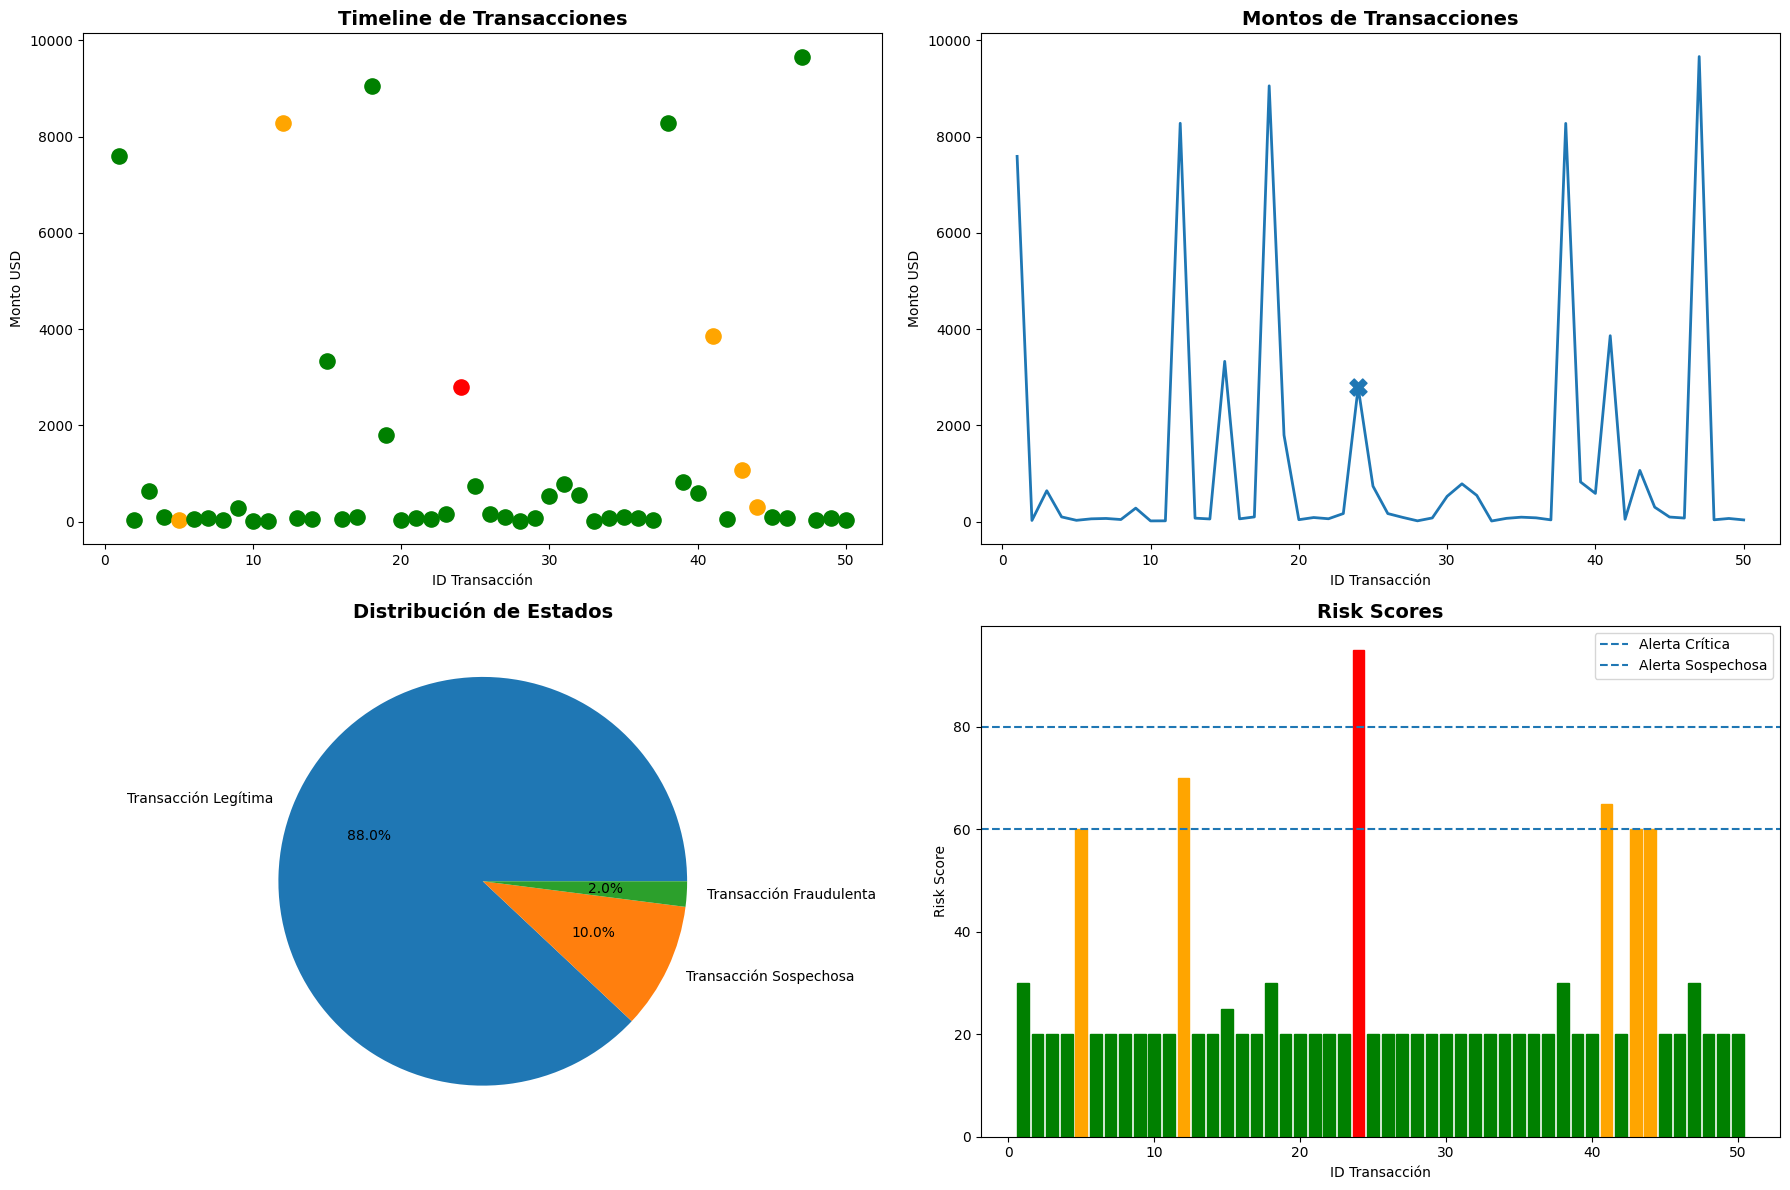


COMPARACIÓN REAL VS VITERBI
               Estado Real       Estado Inferido
0     Transacción Legítima  Transacción Legítima
1     Transacción Legítima  Transacción Legítima
2     Transacción Legítima  Transacción Legítima
3     Transacción Legítima  Transacción Legítima
4   Transacción Sospechosa  Transacción Legítima
5     Transacción Legítima  Transacción Legítima
6     Transacción Legítima  Transacción Legítima
7     Transacción Legítima  Transacción Legítima
8     Transacción Legítima  Transacción Legítima
9     Transacción Legítima  Transacción Legítima
10    Transacción Legítima  Transacción Legítima
11  Transacción Sospechosa  Transacción Legítima
12    Transacción Legítima  Transacción Legítima
13    Transacción Legítima  Transacción Legítima
14    Transacción Legítima  Transacción Legítima

Archivo CSV exportado correctamente.
Nombre: transacciones_fraude_hmm.csv

RESUMEN EJECUTIVO

El sistema HMM simuló 50 transacciones
financieras y aplicó inferencia probabilística median

In [ ]:
# ============================================================
# MODELO OCULTO DE MARKOV (HMM) PARA DETECCIÓN DE FRAUDE
# ============================================================
# Autor: ChatGPT
# Compatible con Google Colab
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

np.random.seed(42)
random.seed(42)

# ============================================================
# CLASE HMM PARA DETECCIÓN DE FRAUDE
# ============================================================

class FraudDetectionHMM:

    def __init__(self):

        # Estados ocultos
        self.states = [
            'Transacción Legítima',
            'Transacción Sospechosa',
            'Transacción Fraudulenta'
        ]

        # Observaciones
        self.observations = [
            'Monto Bajo',
            'Monto Medio',
            'Monto Alto'
        ]

        # Distribución inicial
        self.initial_probs = np.array([0.7, 0.2, 0.1])

        # Matriz de transición
        self.transition_matrix = np.array([
            [0.8, 0.15, 0.05],  # Desde legítima
            [0.4, 0.4, 0.2],    # Desde sospechosa
            [0.1, 0.3, 0.6]     # Desde fraudulenta
        ])

        # Matriz de emisión
        self.emission_matrix = np.array([
            [0.6, 0.3, 0.1],  # Legítima
            [0.3, 0.4, 0.3],  # Sospechosa
            [0.1, 0.3, 0.6]   # Fraudulenta
        ])

        # Colores para visualización
        self.colors = {
            'Transacción Legítima': 'green',
            'Transacción Sospechosa': 'orange',
            'Transacción Fraudulenta': 'red'
        }

    # ========================================================
    # GENERAR MONTO REAL
    # ========================================================

    def generate_real_amount(self, observation):

        if observation == 'Monto Bajo':
            return round(np.random.uniform(10, 100), 2)

        elif observation == 'Monto Medio':
            return round(np.random.uniform(100, 1000), 2)

        elif observation == 'Monto Alto':
            return round(np.random.uniform(1000, 10000), 2)

    # ========================================================
    # SISTEMA DE SCORING DE RIESGO
    # ========================================================

    def calculate_risk_score(self, state, amount):

        base_scores = {
            'Transacción Legítima': 20,
            'Transacción Sospechosa': 60,
            'Transacción Fraudulenta': 90
        }

        score = base_scores[state]

        # Ajuste por monto
        if amount > 5000:
            score += 10
        elif amount > 2000:
            score += 5

        return min(score, 100)

    # ========================================================
    # SIMULAR TRANSACCIONES
    # ========================================================

    def simulate_transactions(self, n_transactions=50):

        hidden_states = []
        observed_categories = []
        real_amounts = []
        risk_scores = []
        alerts = []

        # Estado inicial
        current_state = np.random.choice(
            self.states,
            p=self.initial_probs
        )

        for i in range(n_transactions):

            hidden_states.append(current_state)

            state_index = self.states.index(current_state)

            # Generar observación
            observation = np.random.choice(
                self.observations,
                p=self.emission_matrix[state_index]
            )

            observed_categories.append(observation)

            # Generar monto real
            amount = self.generate_real_amount(observation)
            real_amounts.append(amount)

            # Calcular score de riesgo
            risk_score = self.calculate_risk_score(
                current_state,
                amount
            )

            risk_scores.append(risk_score)

            # Generar alertas
            if risk_score >= 80:
                alert = "🚨 ALERTA CRÍTICA"
            elif risk_score >= 60:
                alert = "⚠️ ALERTA SOSPECHOSA"
            else:
                alert = "✅ Normal"

            alerts.append(alert)

            # Transición al siguiente estado
            current_state = np.random.choice(
                self.states,
                p=self.transition_matrix[state_index]
            )

        # Crear DataFrame
        df = pd.DataFrame({
            'ID_Transaccion': range(1, n_transactions + 1),
            'Estado_Real': hidden_states,
            'Categoria_Monto': observed_categories,
            'Monto_USD': real_amounts,
            'Risk_Score': risk_scores,
            'Alerta': alerts
        })

        return df

    # ========================================================
    # ALGORITMO DE VITERBI
    # ========================================================

    def viterbi(self, observations_sequence):

        n_states = len(self.states)
        T = len(observations_sequence)

        obs_indices = [
            self.observations.index(obs)
            for obs in observations_sequence
        ]

        # Matrices
        viterbi_matrix = np.zeros((n_states, T))
        backpointer = np.zeros((n_states, T), dtype=int)

        # Inicialización
        for s in range(n_states):
            viterbi_matrix[s, 0] = (
                self.initial_probs[s] *
                self.emission_matrix[s, obs_indices[0]]
            )

        # Recursión
        for t in range(1, T):

            for s in range(n_states):

                transition_probs = (
                    viterbi_matrix[:, t-1] *
                    self.transition_matrix[:, s]
                )

                best_prev_state = np.argmax(transition_probs)

                viterbi_matrix[s, t] = (
                    transition_probs[best_prev_state] *
                    self.emission_matrix[s, obs_indices[t]]
                )

                backpointer[s, t] = best_prev_state

        # Backtracking
        best_path = np.zeros(T, dtype=int)

        best_path[T - 1] = np.argmax(viterbi_matrix[:, T - 1])

        for t in range(T - 2, -1, -1):
            best_path[t] = backpointer[
                best_path[t + 1], t + 1
            ]

        inferred_states = [
            self.states[i]
            for i in best_path
        ]

        return inferred_states

    # ========================================================
    # MÉTRICAS DE SEGURIDAD
    # ========================================================

    def calculate_metrics(self, df, inferred_states):

        total_transactions = len(df)

        # Fraudes reales
        real_frauds = df[
            df['Estado_Real'] == 'Transacción Fraudulenta'
        ]

        # Fraudes detectados
        detected_frauds = sum([
            1 for real, inferred in zip(
                df['Estado_Real'],
                inferred_states
            )
            if (
                real == 'Transacción Fraudulenta' and
                inferred == 'Transacción Fraudulenta'
            )
        ])

        # Tasa de detección
        fraud_detection_rate = (
            detected_frauds / max(len(real_frauds), 1)
        ) * 100

        # Falsos positivos
        false_positives = sum([
            1 for real, inferred in zip(
                df['Estado_Real'],
                inferred_states
            )
            if (
                real == 'Transacción Legítima' and
                inferred != 'Transacción Legítima'
            )
        ])

        # Monto total en riesgo
        risk_amount = df[
            df['Risk_Score'] >= 60
        ]['Monto_USD'].sum()

        # Tiempo promedio hasta detectar fraude
        fraud_indices = [
            i for i, state in enumerate(df['Estado_Real'])
            if state == 'Transacción Fraudulenta'
        ]

        avg_detection_time = (
            np.mean(fraud_indices)
            if fraud_indices else 0
        )

        metrics = {
            'Total Transacciones': total_transactions,
            'Fraudes Reales': len(real_frauds),
            'Fraudes Detectados': detected_frauds,
            'Tasa de Detección (%)': round(fraud_detection_rate, 2),
            'Falsos Positivos': false_positives,
            'Monto Total en Riesgo ($)': round(risk_amount, 2),
            'Tiempo Promedio Detección': round(avg_detection_time, 2)
        }

        return metrics

    # ========================================================
    # ANÁLISIS DE PATRONES
    # ========================================================

    def analyze_patterns(self, df):

        print("\n" + "="*60)
        print("ANÁLISIS DE PATRONES DE FRAUDE")
        print("="*60)

        # Distribución de estados
        state_counts = Counter(df['Estado_Real'])

        print("\nDistribución de Estados:")
        for state, count in state_counts.items():
            print(f"- {state}: {count}")

        # Promedio de montos por estado
        print("\nPromedio de Montos por Estado:")

        avg_amounts = df.groupby(
            'Estado_Real'
        )['Monto_USD'].mean()

        for state, avg in avg_amounts.items():
            print(f"- {state}: ${avg:.2f}")

        # Riesgo promedio
        print("\nRisk Score Promedio:")

        avg_risk = df.groupby(
            'Estado_Real'
        )['Risk_Score'].mean()

        for state, avg in avg_risk.items():
            print(f"- {state}: {avg:.2f}")

        # Transacciones críticas
        critical = df[df['Risk_Score'] >= 80]

        print(f"\nTransacciones Críticas Detectadas: {len(critical)}")

    # ========================================================
    # DASHBOARD DE MONITOREO
    # ========================================================

    def create_dashboard(self, df):

        fig, axes = plt.subplots(2, 2, figsize=(18, 12))

        # ====================================================
        # 1. Timeline de transacciones
        # ====================================================

        ax1 = axes[0, 0]

        for i, row in df.iterrows():

            ax1.scatter(
                row['ID_Transaccion'],
                row['Monto_USD'],
                color=self.colors[row['Estado_Real']],
                s=120
            )

        ax1.set_title(
            'Timeline de Transacciones',
            fontsize=14,
            fontweight='bold'
        )

        ax1.set_xlabel('ID Transacción')
        ax1.set_ylabel('Monto USD')

        # ====================================================
        # 2. Gráfico de montos
        # ====================================================

        ax2 = axes[0, 1]

        ax2.plot(
            df['ID_Transaccion'],
            df['Monto_USD'],
            linewidth=2
        )

        frauds = df[
            df['Estado_Real'] == 'Transacción Fraudulenta'
        ]

        ax2.scatter(
            frauds['ID_Transaccion'],
            frauds['Monto_USD'],
            s=150,
            marker='X'
        )

        ax2.set_title(
            'Montos de Transacciones',
            fontsize=14,
            fontweight='bold'
        )

        ax2.set_xlabel('ID Transacción')
        ax2.set_ylabel('Monto USD')

        # ====================================================
        # 3. Distribución de estados
        # ====================================================

        ax3 = axes[1, 0]

        state_counts = df['Estado_Real'].value_counts()

        ax3.pie(
            state_counts,
            labels=state_counts.index,
            autopct='%1.1f%%'
        )

        ax3.set_title(
            'Distribución de Estados',
            fontsize=14,
            fontweight='bold'
        )

        # ====================================================
        # 4. Risk Scores
        # ====================================================

        ax4 = axes[1, 1]

        bars = ax4.bar(
            df['ID_Transaccion'],
            df['Risk_Score']
        )

        # Colorear barras
        for i, bar in enumerate(bars):

            score = df.iloc[i]['Risk_Score']

            if score >= 80:
                bar.set_color('red')
            elif score >= 60:
                bar.set_color('orange')
            else:
                bar.set_color('green')

        ax4.axhline(
            y=80,
            linestyle='--',
            label='Alerta Crítica'
        )

        ax4.axhline(
            y=60,
            linestyle='--',
            label='Alerta Sospechosa'
        )

        ax4.set_title(
            'Risk Scores',
            fontsize=14,
            fontweight='bold'
        )

        ax4.set_xlabel('ID Transacción')
        ax4.set_ylabel('Risk Score')

        ax4.legend()

        plt.tight_layout()
        plt.show()

# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================

print("="*70)
print("SISTEMA HMM PARA DETECCIÓN DE FRAUDE FINANCIERO")
print("="*70)

# Crear modelo
model = FraudDetectionHMM()

# Simular transacciones
df_transactions = model.simulate_transactions(50)

# Ejecutar Viterbi
inferred_states = model.viterbi(
    df_transactions['Categoria_Monto'].tolist()
)

# Agregar inferencias
df_transactions['Estado_Inferido'] = inferred_states

# ============================================================
# MOSTRAR TRANSACCIONES
# ============================================================

print("\nPRIMERAS TRANSACCIONES SIMULADAS:")
print(df_transactions.head(10))

# ============================================================
# MÉTRICAS DE SEGURIDAD
# ============================================================

metrics = model.calculate_metrics(
    df_transactions,
    inferred_states
)

print("\n" + "="*60)
print("MÉTRICAS DE SEGURIDAD")
print("="*60)

for metric, value in metrics.items():
    print(f"{metric}: {value}")

# ============================================================
# ALERTAS AUTOMÁTICAS
# ============================================================

print("\n" + "="*60)
print("ALERTAS AUTOMÁTICAS")
print("="*60)

critical_alerts = df_transactions[
    df_transactions['Risk_Score'] >= 80
]

if len(critical_alerts) > 0:

    for _, row in critical_alerts.iterrows():

        print(
            f"""
🚨 FRAUDE DETECTADO
----------------------------------------
Transacción ID: {row['ID_Transaccion']}
Monto: ${row['Monto_USD']:.2f}
Estado: {row['Estado_Real']}
Risk Score: {row['Risk_Score']}
"""
        )

else:
    print("No se detectaron fraudes críticos.")

# ============================================================
# ANÁLISIS DE PATRONES
# ============================================================

model.analyze_patterns(df_transactions)

# ============================================================
# DASHBOARD
# ============================================================

model.create_dashboard(df_transactions)

# ============================================================
# MATRIZ DE CONFUSIÓN SIMPLE
# ============================================================

print("\n" + "="*60)
print("COMPARACIÓN REAL VS VITERBI")
print("="*60)

comparison = pd.DataFrame({
    'Estado Real': df_transactions['Estado_Real'],
    'Estado Inferido': df_transactions['Estado_Inferido']
})

print(comparison.head(15))

# ============================================================
# EXPORTAR RESULTADOS
# ============================================================

df_transactions.to_csv(
    'transacciones_fraude_hmm.csv',
    index=False
)

print("\nArchivo CSV exportado correctamente.")
print("Nombre: transacciones_fraude_hmm.csv")

# ============================================================
# RESUMEN EJECUTIVO
# ============================================================

print("\n" + "="*70)
print("RESUMEN EJECUTIVO")
print("="*70)

print(f"""
El sistema HMM simuló {len(df_transactions)} transacciones
financieras y aplicó inferencia probabilística mediante
el algoritmo de Viterbi.

Características implementadas:
✔ Modelo Oculto de Markov
✔ Simulación de fraude financiero
✔ Sistema de scoring de riesgo
✔ Dashboard visual
✔ Alertas automáticas
✔ Análisis de patrones
✔ Métricas de seguridad
✔ Inferencia probabilística
✔ Exportación de resultados

Este sistema puede ser utilizado como base para:
- Motores antifraude bancario
- Monitoreo de pagos digitales
- Detección temprana de anomalías
- Sistemas de ciberseguridad financiera
""")